# Model Performance Comparison

This notebook loads all exported evaluation metrics from trained models and visualises their performance using:
- A grouped bar chart (all metrics side-by-side per model)
- A radar chart (strengths/weaknesses at a glance)
- A Precision–Recall scatter plot
- A ROC AUC bar chart (sorted)
- A styled summary table with best values highlighted


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 120,
})

In [2]:
metric_files = glob.glob("RESULTS/PERFORMANCE/*_metrics.csv")

comparison_df = pd.concat(
    [pd.read_csv(f) for f in metric_files],
    ignore_index=True
)

comparison_df = comparison_df[
    ["Strategy", "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"]
].sort_values(by=["ROC AUC"], ascending=False).reset_index(drop=True)

comparison_df


,Strategy,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Random undersampling,XGBoost,0.723899,0.385585,0.779022,0.515846,0.825095
1,SMOTE oversampling,XGBoost,0.821573,0.536885,0.400204,0.458576,0.819955
2,Random undersampling,Random Forest,0.718323,0.378460,0.765784,0.506568,0.817916
3,Random undersampling,Logistic Regression,0.716785,0.374553,0.746436,0.498809,0.810117
4,SMOTE oversampling,Random Forest,0.803499,0.479339,0.472505,0.475897,0.809018
5,SMOTE oversampling,Logistic Regression,0.711978,0.367556,0.729124,0.488737,0.802213
6,Random undersampling,Decision Tree,0.704288,0.359169,0.721996,0.479702,0.779707
7,SMOTE oversampling,Decision Tree,0.703134,0.345264,0.638493,0.448177,0.755653


In [3]:
# Assign consistent colors and labels per model-strategy combination
MODEL_COLORS = {
    "Logistic Regression": "#3266ad",
    "Random Forest":       "#2a8a5e",
    "XGBoost":             "#a04e0a",
    "Decision Tree":       "#7a3090",
}

STRATEGY_HATCHES = {
    "SMOTE oversampling": "",
    "Random undersampling": "//",
}

comparison_df["label"] = comparison_df["Model"] + " / " + comparison_df["Strategy"]
comparison_df["color"] = comparison_df["Model"].map(MODEL_COLORS)
comparison_df["hatch"] = comparison_df["Strategy"].map(STRATEGY_HATCHES)

METRICS = ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"]


## 1. Grouped Bar Chart — All Metrics

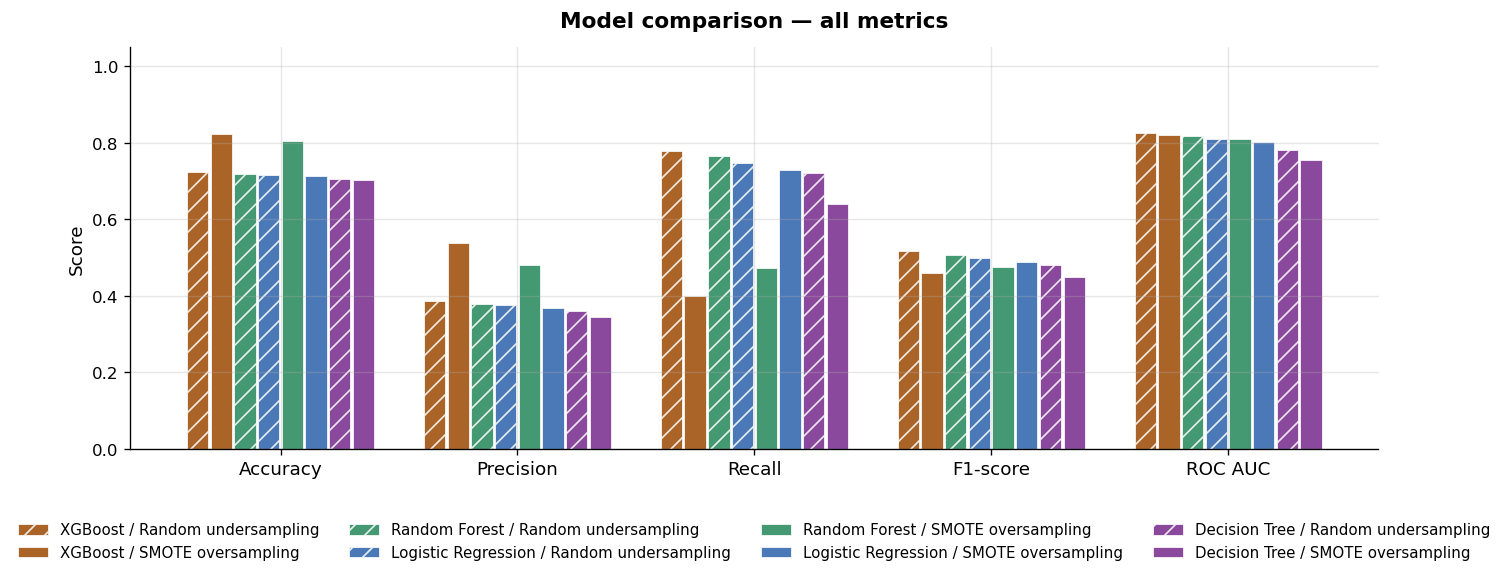

In [4]:
n_models = len(comparison_df)
n_metrics = len(METRICS)
x = np.arange(n_metrics)
width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(13, 5))

for i, (_, row) in enumerate(comparison_df.iterrows()):
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(
        x + offset,
        [row[m] for m in METRICS],
        width=width * 0.9,
        label=row["label"],
        color=row["color"],
        hatch=row["hatch"],
        edgecolor="white",
        linewidth=0.5,
        alpha=0.88,
    )

ax.set_xticks(x)
ax.set_xticklabels(METRICS, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model comparison — all metrics", fontsize=13, fontweight="bold", pad=12)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=9,
    frameon=False,
)

plt.tight_layout()
plt.savefig("RESULTS/CHARTS/comparison_grouped_bar.png", bbox_inches="tight")
plt.show()


## 2. Radar Chart — Strengths & Weaknesses

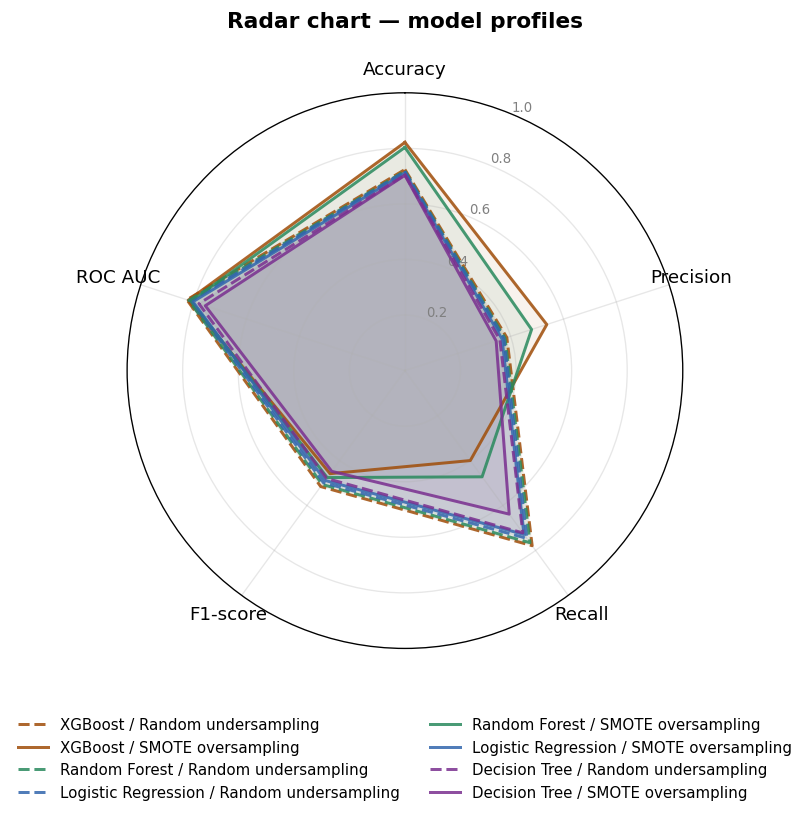

In [5]:
angles = np.linspace(0, 2 * np.pi, len(METRICS), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in comparison_df.iterrows():
    values = [row[m] for m in METRICS]
    values += values[:1]
    ax.plot(angles, values, color=row["color"],
            linestyle="--" if row["hatch"] else "-",
            linewidth=1.8, alpha=0.85, label=row["label"])
    ax.fill(angles, values, color=row["color"], alpha=0.07)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), METRICS, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8, color="gray")
ax.set_title("Radar chart — model profiles", fontsize=13, fontweight="bold", pad=20)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=2,
    fontsize=9,
    frameon=False,
)

plt.tight_layout()
plt.savefig("RESULTS/CHARTS/comparison_radar.png", bbox_inches="tight")
plt.show()


## 3. Precision–Recall Scatter

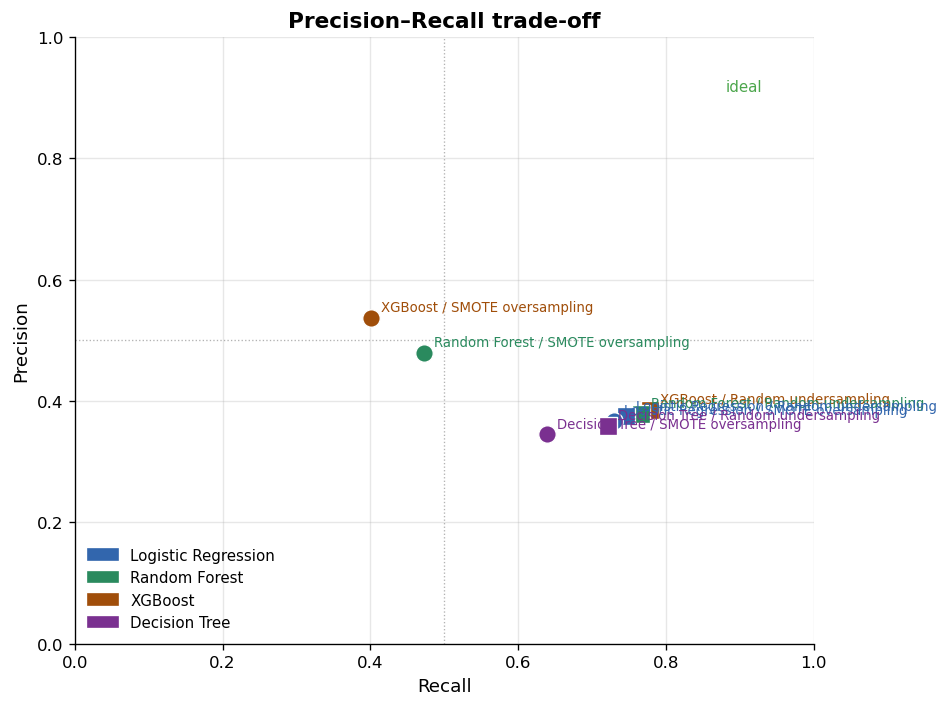

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in comparison_df.iterrows():
    marker = "o" if row["hatch"] == "" else ("s" if row["hatch"] == "//" else "^")
    ax.scatter(row["Recall"], row["Precision"],
            color=row["color"], s=110, marker=marker,
            edgecolors="white", linewidths=0.8, zorder=3, label=row["label"])
    ax.annotate(
        row["label"],
        (row["Recall"], row["Precision"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
        color=row["color"],
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision–Recall trade-off", fontsize=13, fontweight="bold")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
ax.axvline(0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
ax.text(0.93, 0.93, "ideal", fontsize=9, color="green", ha="right", va="top",
        transform=ax.transAxes, alpha=0.7)

handles = []
for model, color in MODEL_COLORS.items():
    handles.append(mpatches.Patch(color=color, label=model))
ax.legend(handles=handles, fontsize=9, frameon=False,
    loc="lower left", bbox_to_anchor=(0, 0))

plt.tight_layout()
plt.savefig("RESULTS/CHARTS/comparison_pr_scatter.png", bbox_inches="tight")
plt.show()


## 4. ROC AUC Ranking

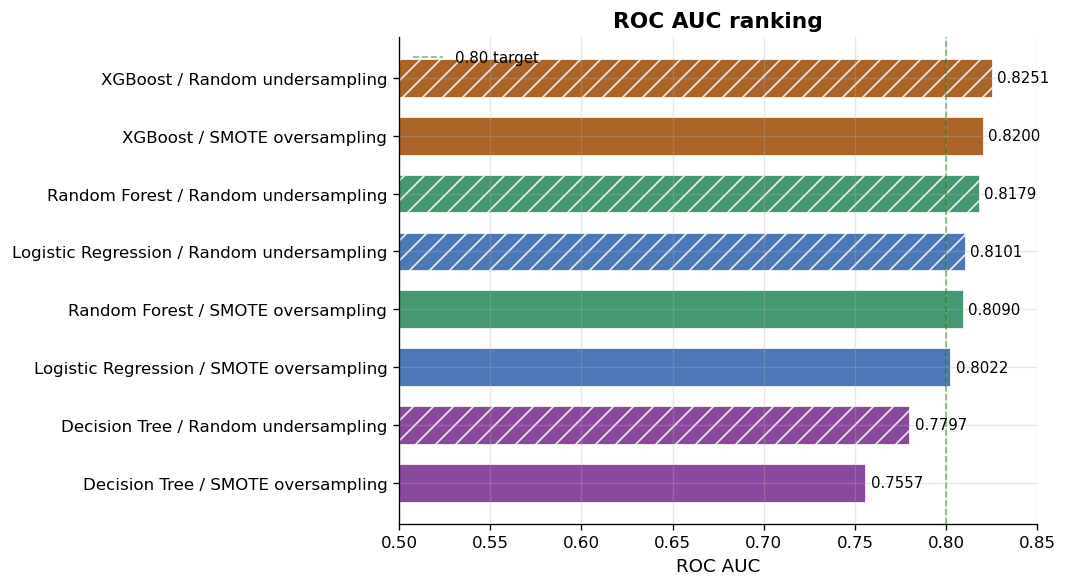

In [7]:
roc_df = comparison_df.sort_values("ROC AUC", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    roc_df["label"],
    roc_df["ROC AUC"],
    color=roc_df["color"],
    hatch=roc_df["hatch"],
    edgecolor="white",
    linewidth=0.5,
    height=0.65,
    alpha=0.88,
)

for bar, val in zip(bars, roc_df["ROC AUC"]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)

ax.set_xlim(0.5, 0.85)
ax.set_xlabel("ROC AUC", fontsize=11)
ax.set_title("ROC AUC ranking", fontsize=13, fontweight="bold")
ax.axvline(0.8, color="green", linestyle="--", linewidth=1, alpha=0.5, label="0.80 target")
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("RESULTS/CHARTS/comparison_roc_auc.png", bbox_inches="tight")
plt.show()


## 5. Summary Table — Best Values Highlighted

In [8]:
display_df = comparison_df[["Strategy", "Model"] + METRICS].copy()
display_df[METRICS] = display_df[METRICS].round(4)

def highlight_best(s):
    is_best = s == s.max()
    return ["background-color: #d4edda; font-weight: bold" if v else "" for v in is_best]

styled = (
    display_df.style
    .apply(highlight_best, subset=METRICS)
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("padding", "6px 12px")]},
    ])
    .hide(axis="index")
)

styled


Strategy,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
Random undersampling,XGBoost,0.723900,0.385600,0.779000,0.515800,0.825100
SMOTE oversampling,XGBoost,0.821600,0.536900,0.400200,0.458600,0.820000
Random undersampling,Random Forest,0.718300,0.378500,0.765800,0.506600,0.817900
Random undersampling,Logistic Regression,0.716800,0.374600,0.746400,0.498800,0.810100
SMOTE oversampling,Random Forest,0.803500,0.479300,0.472500,0.475900,0.809000
SMOTE oversampling,Logistic Regression,0.712000,0.367600,0.729100,0.488700,0.802200
Random undersampling,Decision Tree,0.704300,0.359200,0.722000,0.479700,0.779700
SMOTE oversampling,Decision Tree,0.703100,0.345300,0.638500,0.448200,0.755700


In [9]:
print("=== Best score per metric ===")
for m in METRICS:
    best = comparison_df.loc[comparison_df[m].idxmax()]
    print(f"  {m:<12} {best[m]:.4f}  →  {best['Model']} ({best['Strategy']})")


=== Best score per metric ===
  Accuracy     0.8216  →  XGBoost (SMOTE oversampling)
  Precision    0.5369  →  XGBoost (SMOTE oversampling)
  Recall       0.7790  →  XGBoost (Random undersampling)
  F1-score     0.5158  →  XGBoost (Random undersampling)
  ROC AUC      0.8251  →  XGBoost (Random undersampling)
